<a href="https://colab.research.google.com/github/smaldonado2004/labo_de_datos/blob/main/clase5_ldd_regresionlineal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Nuevas librerías

Utilizaremos el módulo `scikit-learn` y `formulaic` de Python. Para instalarlos, correr:

In [1]:
 !pip install scikit-learn
 !pip install formulaic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 4.6 MB/s eta 0:00:00


Importamos los módulos de siempre, las herramientas de modelos lineales y las medidas de desempeño del modelo de `scikit-learn`:

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import seaborn.objects as so

#Esta herramienta permite escribir el modelo en notación de Wilkinson, por ejemplo: Y ~ X
#no calcula nada por sí sola. Solo sirve para definir cómo se relacionan las variables, es decir,
#especificar qué variable se quiere predecir (Y) y cuál se usa como predictora (X).
from formulaic import Formula

# Herramientas de modelos lineales Calcula B0 y B1:
from sklearn import linear_model

# Medidas de desempeño Diferentes errores:
    #mean_squared_error: para ECM
    #r2_score: para R^2
    #root_mean_squared_error: para RECM:
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error

### Modelo de Regresión Lineal

Queremos utilizar un modelo lineal:
$$ Y = \beta_0 + \beta_1 X $$
para intentar predecir valores continuos.

### Visualización

Con lo que hemos visto las clases anteriores, visualizar la recta que mejor aproxima a los datos en el sentido de cuadrados mínimos es relativamente sencillo con `seaborn objects`, ya que `seaborn` calcula automáticamente los valores de $\beta_0$ y $\beta_1$.

Utilizaremos el dataset _tips_ de `seaborn` y analizaremos la relación entre lo que costó la comida y la cantidad de propina.

In [3]:
datos = sns.load_dataset('tips')

In [4]:
datos

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


Visualizamos los datos con `so.Plot`

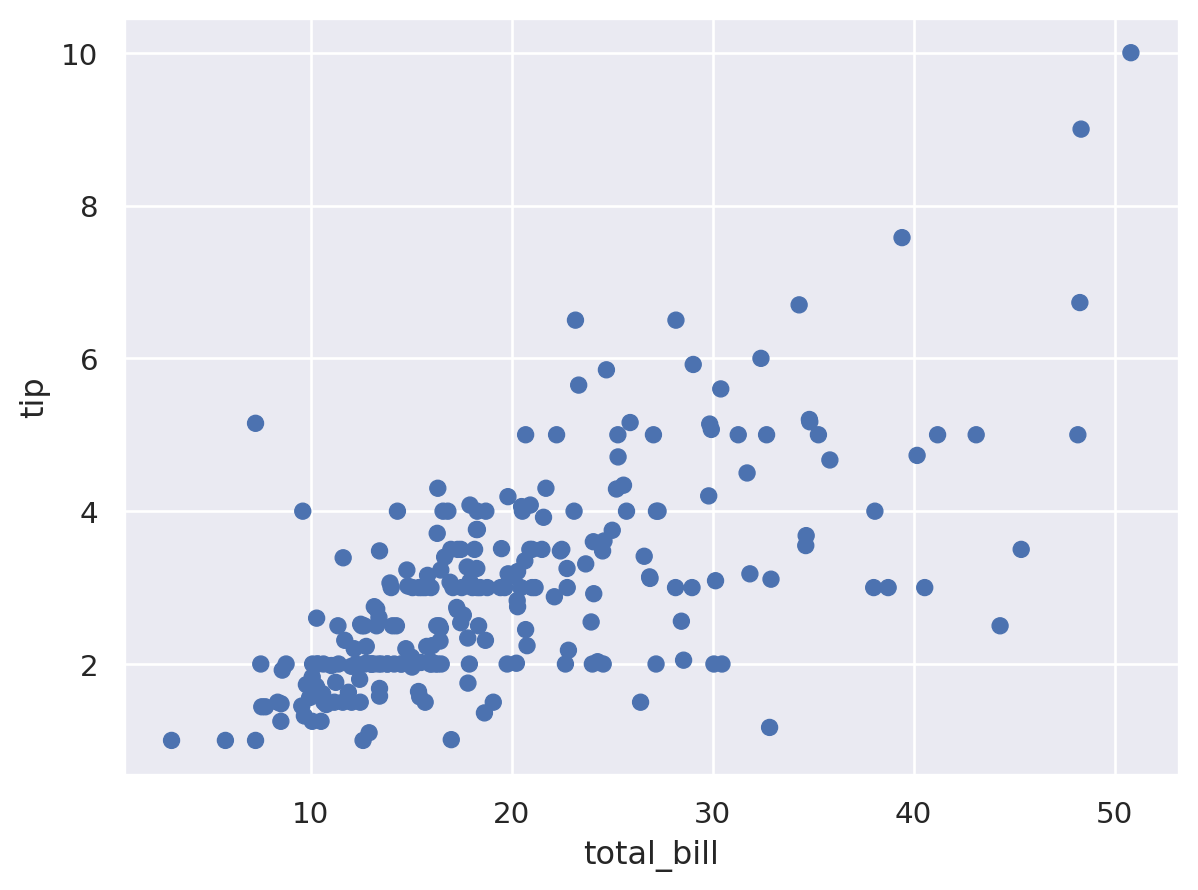

In [ ]:
# Graficamos la relacion entre las variables

(
    so.Plot(data=datos, x='total_bill', y='tip')
    .add(so.Dot())
)

Para visualizar la recta de la regresión, agregamos una línea al gráfico (`so.Line()`) junto a `so.PolyFit(1)`:

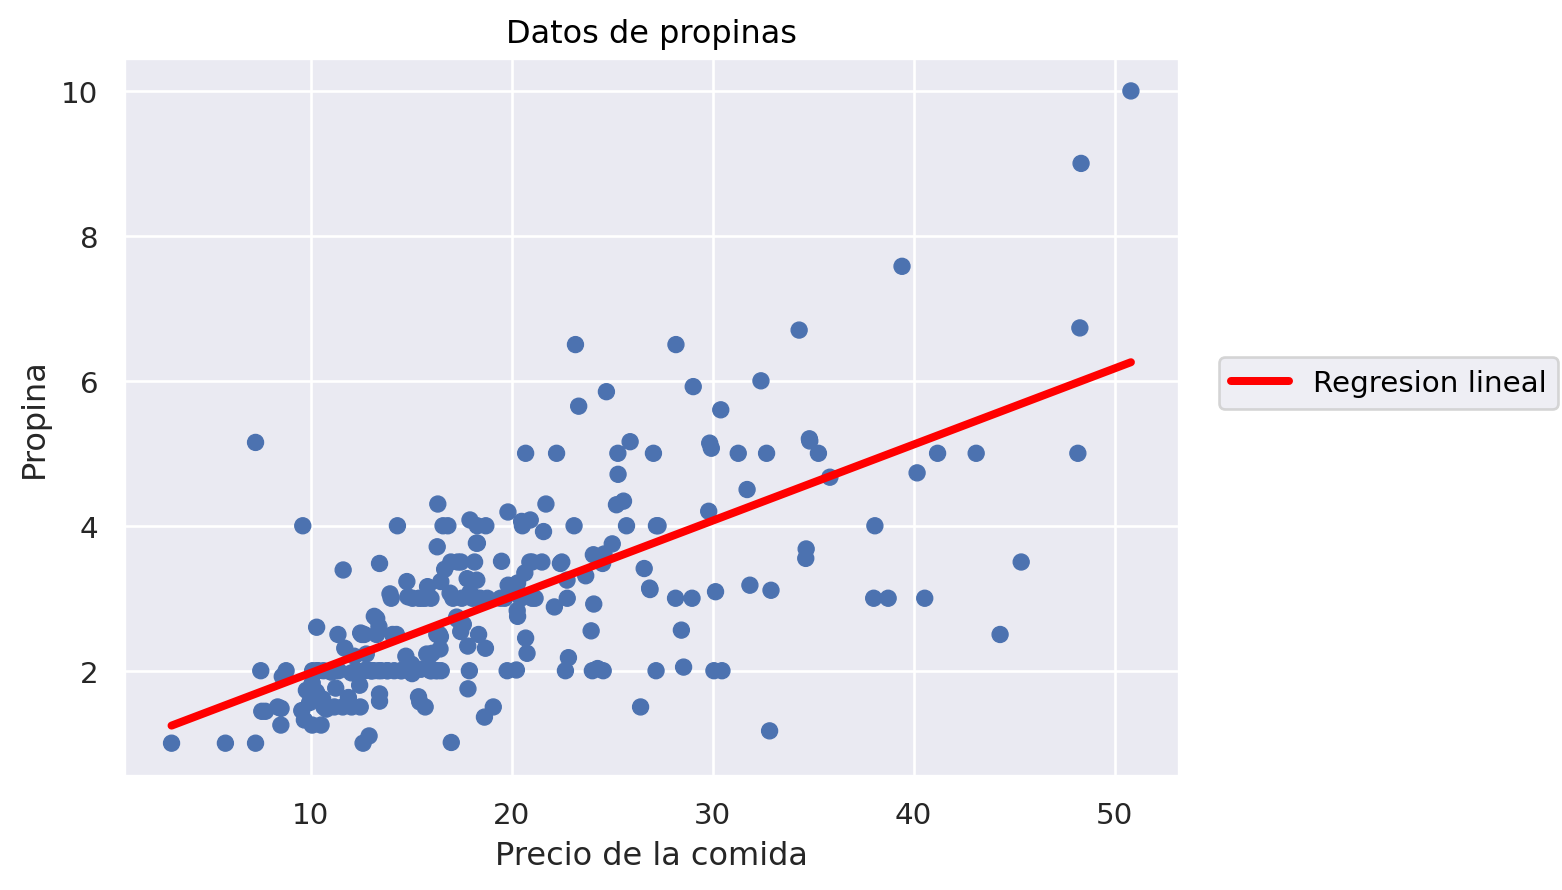

In [ ]:
(
    so.Plot(data=datos, x='total_bill', y='tip')
    .add(so.Dot())

    .add(so.Line(color='red', linewidth=3), so.PolyFit(1), label='Regresion lineal')
    #aca puse mi m. lineal con una linea roja de GROSOR 3,
    # so.PolyFit(1) está calculando automáticamente la recta que mejor ajusta los datos, es decir, está encontrando β0 y B1
        #El número 1 indica el grado del polinomio: en este caso una f. lineal
    #label: poner normbre solo en esa capa

    .label(title='Datos de propinas', x='Precio de la comida', y='Propina')    # Agregamos la leyenda, un titulo y le cambiamos el nombre a los ejes
)

### Cálculo de coeficientes y predicciones

Desafortunamente, `seaborn` no nos devuelve los valores de $\beta_0$ y $\beta_1$, que son importantes en la interpretación del resultado.

Hemos visto que podemos calcular los coeficientes de la regresión lineal como:

 $$
 \begin{array}{rl}
      \hat{\beta}_1 = & \dfrac{\displaystyle\sum_{i=1}^n(x_i - \bar{x})(y_i - \bar{y})}{\displaystyle\sum_{i=1}^n(x_i - \bar{x})^2}  \\[1em]
      \hat{\beta}_0 = & \bar{y} - \hat{\beta}_1\bar{x}
 \end{array}
 $$

 pero también podemos utilizar `scikit-learn` y `formulaic`.

Como queremos predecir la propina según el precio de la comida usando una función lineal, la fórmula de Wilkinson es:
$$tip \sim total\_bill$$

Pq era Y ~ X donde Y era predictoria

In [5]:
y, X = Formula('tip ~ total_bill').get_model_matrix(datos)

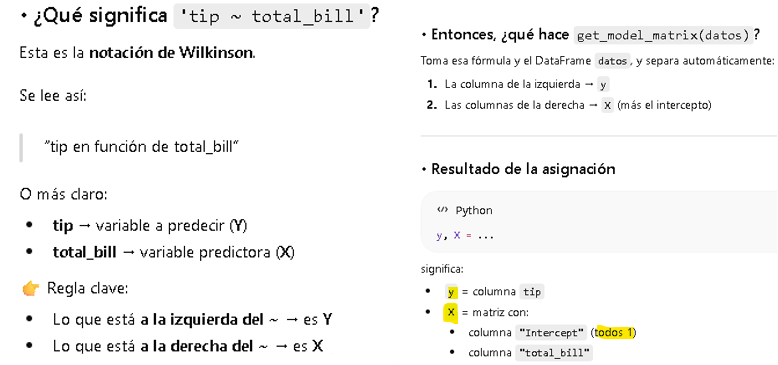

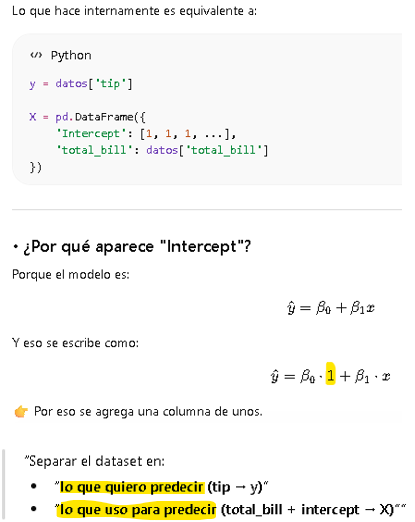

In [7]:
y #o sea uso los tips reales, no los que predice el programa

,tip
0,1.01
1,1.66
2,3.50
3,3.31
4,3.61
...,...
239,5.92
240,2.00
241,2.00
242,1.75


In [6]:
X
#"Intercept" = columna de 1 para calcular β0
#total_bill = variable predictora para calcular β1

,Intercept,total_bill
0,1.0,16.99
1,1.0,10.34
2,1.0,21.01
3,1.0,23.68
4,1.0,24.59
...,...,...
239,1.0,29.03
240,1.0,27.18
241,1.0,22.67
242,1.0,17.82


In [9]:
# Inicializamos el modelo de regresión. OJO DE AHORA EN ADELANDE PARA USARLOS LO LLAMAMOS COMO "modelo":
modelo = linear_model.LinearRegression(fit_intercept=False) # RECORDAR USAR fit_intercept = False

# Realiza el ajuste
modelo.fit(X, y)

# Para obtener los valores de beta_1 y beta_0 como valores numericos
beta = modelo.coef_
beta_0 = beta[0][0]
beta_1 = beta[0][1]
print('Beta_0: ', beta_0)
print('Beta_1: ', beta_1)

Beta_0:  0.9202696135546726
Beta_1:  0.10502451738435345


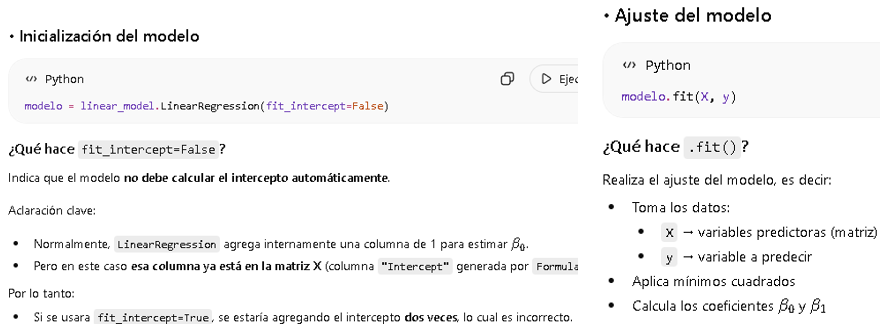

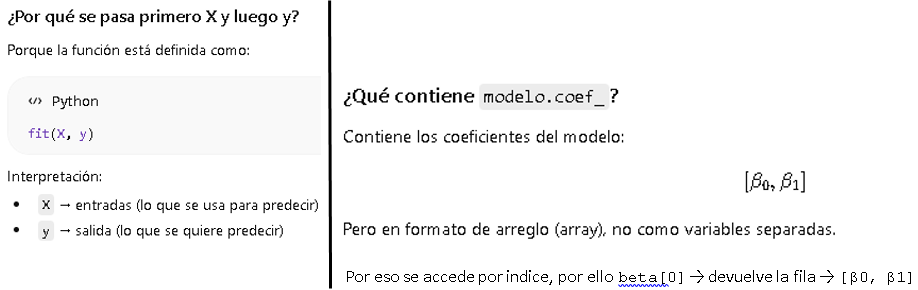

In [ ]:
beta[0]

array([0.92026961, 0.10502452])

Entonces, la recta que mejor aproxima a los datos es (redondeando):
$$ Y = 0.92 + 0.105 X$$

Una interpretación que podemos darle a este resultado es que, por cada peso que costó la comida, se dejan de propina 0.105 pesos (o sea, alrededor de 10 centavos). Esto se debe a que β1 indica el cambio esperado en Y ante un aumento de 1 unidad en X.

En este caso: Si la cuenta aumenta en 1 peso. La propina aumenta en promedio 0.105 pesos. Es decir, aproximadamente un 10.5% del total.

En cambio, la ordenada al origen que seria 0.92 (valor de B0) no siempre tiene una interpretacion, debido a que representa el valor de Y cuando X=0. En mi ejemplo si la cuenta fuera 0, el modelo predice una propina de 0.92. Esto no tiene mucho sentido práctico, porque no existen cuentas de 0 en este contexto.

Con los valores de **$\beta_0$ y $\beta_1$ podemos predecir cuanto será la propina según el valor de la comida**. Por ejemplo: Y=0.92+0.105X, si mi cuenta es 100$ entonces eso es X, y tendriamos: Y=0.92+0.105⋅100= 11.42.

Supongamos que queremos predecir la propina que se deja por una cuenta \\$35. Utilizamos el método `predict()` del modelo.

<span style="color:red">**EL MÉTODO .predict() SOLO ADMITE ADMITE DATAFRAMES (O MATRICES).**</span>

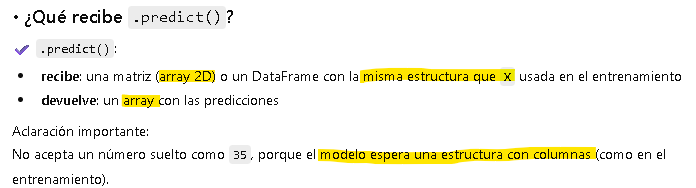

In [10]:
# Creamos un array con los valores a predecir.
x_a_predecir = np.array([35])

# Creamos un DataFrame con los valores de X para los que queremos predecir
# Debe tener una columna de 1's que sea el Intercept
# Los nombres entre comillas tienen q coincidir (Intercept y total_bill) para usarlos con .predict()
dataframe_a_predecir = pd.DataFrame({'Intercept': np.ones(x_a_predecir.shape), 'total_bill': x_a_predecir})
    #x_a_predecir.shape = (1,) :mi nro es [35].shape devuelve 1 pq indica la cant. de datos
    #'Intercept': np.ones(x_a_predecir.shape): en la colum. intercept pone 1 una unica vez: np.ones(1)
    #'total_bill': x_a_predecir: en la colum. total bill va la cuenta total

# Aplicamos la fórmula del modelo:
modelo.predict(dataframe_a_predecir)

array([[4.59612772]])

In [11]:
dataframe_a_predecir

,Intercept,total_bill
0,1.0,35


In [ ]:
# Para devolver directamente el numero agregamos .item()
modelo.predict(dataframe_a_predecir).item()

4.596127722007044

También podemos hacer directamente la cuenta porque ya sabemos cuanto valen $\beta_1$ y $\beta_0$. Sin embargo, en modelos + complejos es mejor usar lo anterior.

In [ ]:
beta_1 * 35 + beta_0

np.float64(4.596127722007044)

Podemos predecir varios valores de una:

In [13]:
# Creamos un array con los valores a predecir
x_a_predecir = np.array([35, 60])

dataframe_a_predecir = pd.DataFrame({'Intercept': np.ones(x_a_predecir.shape), 'total_bill': x_a_predecir})
    #ahora tengo np.ones(2) y total bill dos valores

# Aplicamos la fórmula del modelo
modelo.predict(dataframe_a_predecir)

array([[4.59612772],
       [7.22174066]])

In [14]:
dataframe_a_predecir

,Intercept,total_bill
0,1.0,35
1,1.0,60


Si queremos calcular los valores predichos por el modelo $\hat{y}_i$ para todos nuestros $x_i$:

In [ ]:
y_pred = modelo.predict(X) #mando mi X original con intercept 1 y todos los valores de colum "total_bill"
display(y_pred)

array([[2.70463616],
       [2.00622312],
       [3.12683472],
       [3.40725019],
       [3.5028225 ],
       [3.57633966],
       [1.84133463],
       [3.74332864],
       [2.49983836],
       [2.47253198],
       [1.99887141],
       [4.6234341 ],
       [2.53974767],
       [2.85587147],
       [2.47778321],
       [3.1866987 ],
       [2.00517288],
       [2.631119  ],
       [2.70253567],
       [3.0890259 ],
       [2.80230897],
       [3.05121707],
       [2.57650625],
       [5.06033609],
       [3.00185555],
       [2.79075627],
       [2.32444741],
       [2.25303074],
       [3.19930164],
       [2.98400138],
       [1.92325375],
       [2.84746951],
       [2.50193885],
       [3.09322688],
       [2.78760553],
       [3.4471595 ],
       [2.63321949],
       [2.69833469],
       [2.88317784],
       [4.20438627],
       [2.60486287],
       [2.75399769],
       [2.38431139],
       [1.93690694],
       [4.11301494],
       [2.84116804],
       [3.25496464],
       [4.323

### ¿Qué tan bueno es el modelo?

Finalmente, el bueno de `scikit-learn` nos calcula el coeficiente de determinación $R^ 2$: primero van los datos observados o sea os reales ( $y$ ) y luego los datos predichos (los que calcule con mi modelo) ( $\hat{y}$ )

In [17]:
#predigo los tips de todo lo que estaba en X:
y_pred = modelo.predict(X)

#r2_score compara el valor real, con el valor que predijo mi modelo
r2_score(datos['tip'], y_pred)

0.45661658635167646

De manera análoga podemos calcular el error cuadrático medio (ECM):

In [ ]:
mean_squared_error(datos['tip'], y_pred)

1.036019442011377

Y la raíz del error cuadrático medio:

In [ ]:
root_mean_squared_error(datos['tip'], y_pred)

1.0178504025697377

Esto último podría interpretarse (informalmente) como que al usar el modelo para predecir cuánta propina dejo, en
promedio voy a cometer un error en el margen de $\pm 1.01785$ pesos.

#### Ejercicio

Utilizando el ya calculado `y_pred`, comparar en un mismo gráfico la recta de regresión obtenida con `seaborn objects` (en rojo y etiquetada "Regresion Seaborn") y la que resulta de utilizar `scikit-learn` (en azul y etiqueatada "Regresion Scikit"). El eje `y` debe tener la etiqueta "propina", el eje `x` la etiqueta "precio de la comida".

In [20]:
datos

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [23]:
print(beta_0)
print(beta_1)

0.9202696135546726
0.10502451738435345


In [26]:
#Para contruir una recta necesito dos puntos y si son extremos mejor

#Hallo el min y max para x (total_bill):
x_min= datos['total_bill'].min()
x_max = datos['total_bill'].max()

#Recuerdo y = B0 + B1 X
y_min = beta_0 + beta_1 * x_min
y_max = beta_0 + beta_1 * x_max

#Armo un df con los valores de la recta:
df_y_pred = pd.DataFrame({'total_bill': [x_min, x_max], #primera colum
                          'y_pred': [y_min, y_max]}) #2da colum
display(df_y_pred)

,total_bill,y_pred
0,3.07,1.242695
1,50.81,6.256565


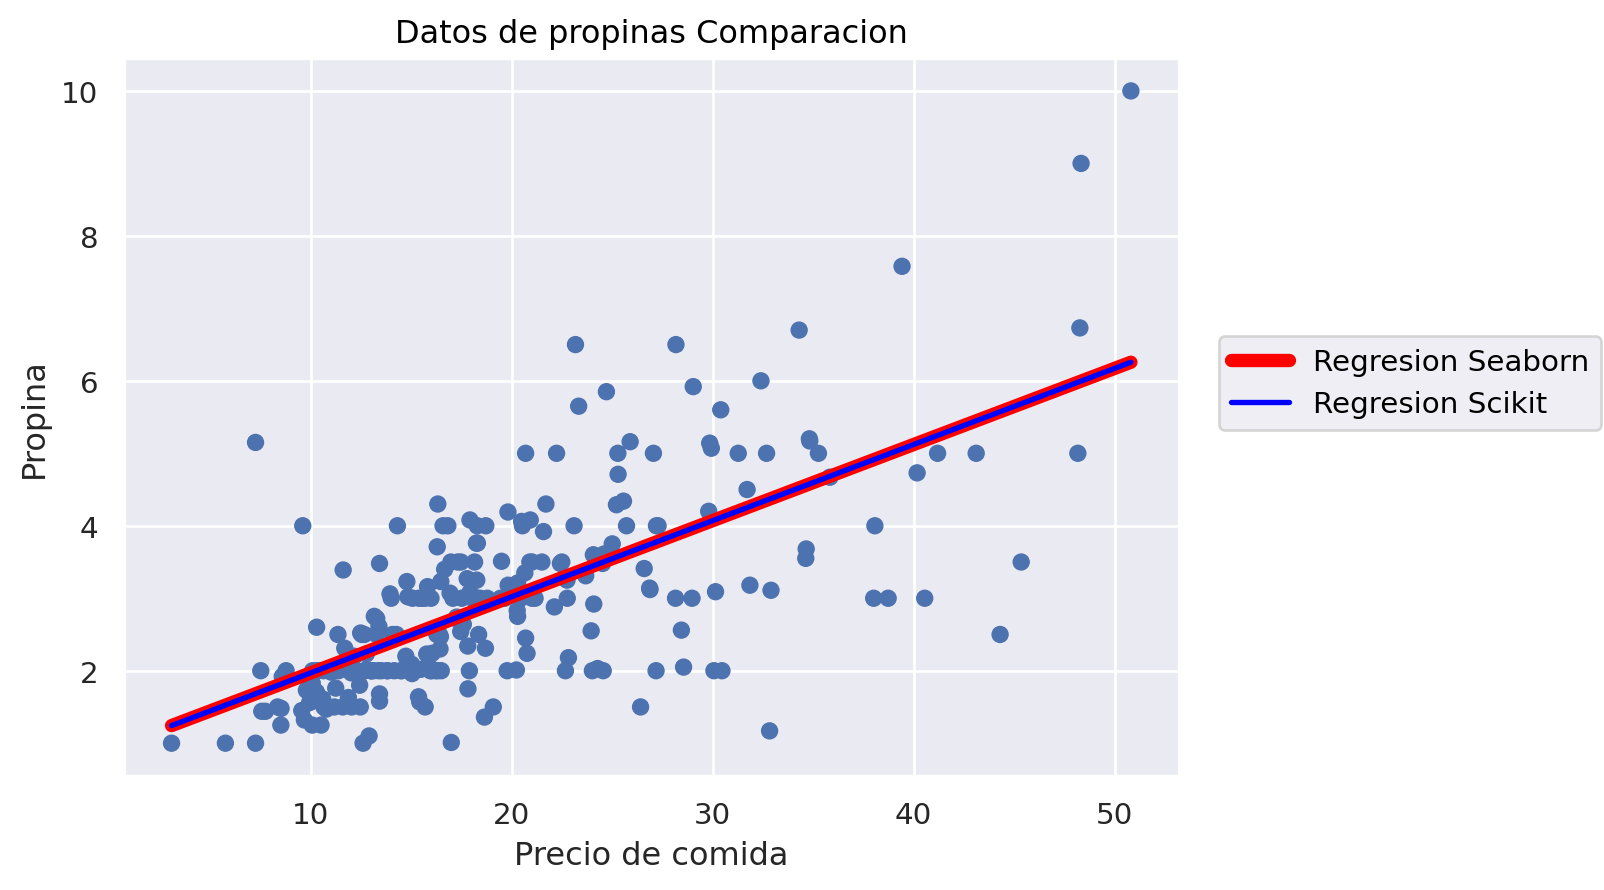

In [29]:
(
    so.Plot(data=datos, x='total_bill', y = 'tip')
    .add(so.Dot())
    .add(so.Line(color='red', linewidth=5), so.PolyFit(1), label='Regresion Seaborn')

    #para la recta calculada con y_pred (nos debe dar la misma q con seaborn pq es la misma regresion lineal):
    #usamos df_y_pred
    .add(so.Line(color = 'blue', linewidth = 2), label= 'Regresion Scikit', data = df_y_pred, x = 'total_bill', y = 'y_pred')
    #al redefinir data, x e y se deja de tomar en cuenta lo q se pidio en .Plot() para esta linea

    .label(title='Datos de propinas Comparacion', x='Precio de comida', y='Propina')
)